In [ ]:
import numpy as np
import json
import pandas as pd
from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt
from ecifp.fp_sim import (get_optimal_cutoff,
                          get_batch_ecifp_sim)
from ecifp.utils import get_ecifp, get_data_dir
import pyarrow as pa
import pyarrow.parquet as pq
import pyarrow.compute as pc
import matplotlib.colors as mcolors
from pyminimax import minimax, fcluster_prototype

In [ ]:
DATADIR = get_data_dir()

In [88]:
def get_clusters(linkage_matrix, labels, ligand_id):
    lig_clusters = {ligand_id:{}}
    cutoff = get_optimal_cutoff(linkage_matrix, 0.3, 0.6)
    
    lig_clusters[ligand_id]["distance_cutoff"] = cutoff
    lig_clusters[ligand_id]["clusters"] = {}
    node_clusters = {}

    cluster = fcluster_prototype(linkage_matrix, cutoff, criterion='distance')
    for cl in np.unique(cluster[:, 0]):
        cluster_id = str(cl)
        lig_clusters[ligand_id]["clusters"][cluster_id] = {}
        cl_indices = np.argwhere(cluster[:, 0]==cl)
        lig_clusters[ligand_id]["clusters"][cluster_id]["complexes"] = labels[cl_indices[:, 0]].tolist()
        lig_clusters[ligand_id]["clusters"][cluster_id]["rep"] = labels[cluster[cl_indices[0, 0], 1]]
    
    # leaves
    for i, c in enumerate(cluster[:, 0]):
        node_clusters[i] = int(c)

    n = len(cluster[:, 0])  
    # internal nodes: index = n + row_number
    for row_idx, (c1, _, dist, _, _) in enumerate(linkage_matrix):
        node_id = n + row_idx
        if dist < cutoff:
            # still below cutoff, inherit child cluster
            node_clusters[node_id] = node_clusters[int(c1)]
        else:
            # above cutoff: keep as its own cluster or default color
            node_clusters[node_id] = -1
    
    return lig_clusters, cutoff, node_clusters

## Binding modes of TL-3

In [ ]:
protein_ligand_ecifp = pq.read_table(DATADIR / "protein_ligand_ecifp.parquet")

In [ ]:
with open(DATADIR / "quality_filtered_complex_ids.json", "r") as f:
    valid_ligand_complexes = json.load(f)

In [ ]:
# mask = pc.is_in(protein_ligand_ecifp['complex_id'], value_set=pa.array(['5fiv_bm2','1b11_bm6','6fiv_bm4','5vea_bm2','2az8_bm2','3kfp_bm2','2azb_bm2','2hah_bm2']))
# filtered_table = protein_ligand_ecifp.filter(pc.invert(mask))
# pq.write_table(filtered_table, '../data/protein_ligand_ecifp.parquet')

In [58]:
ligand_id = "3TL"

In [59]:
mask_1 = pc.equal(protein_ligand_ecifp["ligand_id"], ligand_id)
mask_2 = pc.is_in(protein_ligand_ecifp["complex_id"], pa.array(valid_ligand_complexes.get(ligand_id, [])))
ecifp = protein_ligand_ecifp.filter(pc.and_(mask_1, mask_2))

In [60]:
ligand_ecifp, protein_ecifp = get_ecifp(ecifp,ligand_ecifp_name="ligand_ecifp", protein_ecifp_name="protein_ecifp")

In [61]:
ecifp_sim = get_batch_ecifp_sim(ligand_ecifp, protein_ecifp, 0.4, 0.6)

In [62]:
linkage_matrix = minimax(1-ecifp_sim, True)

In [63]:
def get_chem_comp_ids(entry_chem_comps):
    return ':'.join(f"{entry_chem_comps[0]}_{chem_comp['auth_asym_id']}_{chem_comp['auth_seq_id']}" for chem_comp in entry_chem_comps[1])


In [64]:
complex_ids = ecifp["complex_id"].to_numpy()

In [65]:
chem_comp_ids = list(map(get_chem_comp_ids, zip(ecifp['entry_id'].to_numpy(), ecifp["chem_comps"].to_numpy())))

In [89]:
clusters, cut_off, node_clusters = get_clusters(linkage_matrix, complex_ids, ligand_id)

In [85]:
def link_color_func(k):
    cluster_id = node_clusters[k]
    colors = [(99,183,12),(0,255,255),(245,222,179)]
    custom_colors = {i+1: mcolors.to_hex(tuple(cl/255 for cl in colors[i])) for i in range(len(colors))}
    return custom_colors.get(cluster_id, "black")

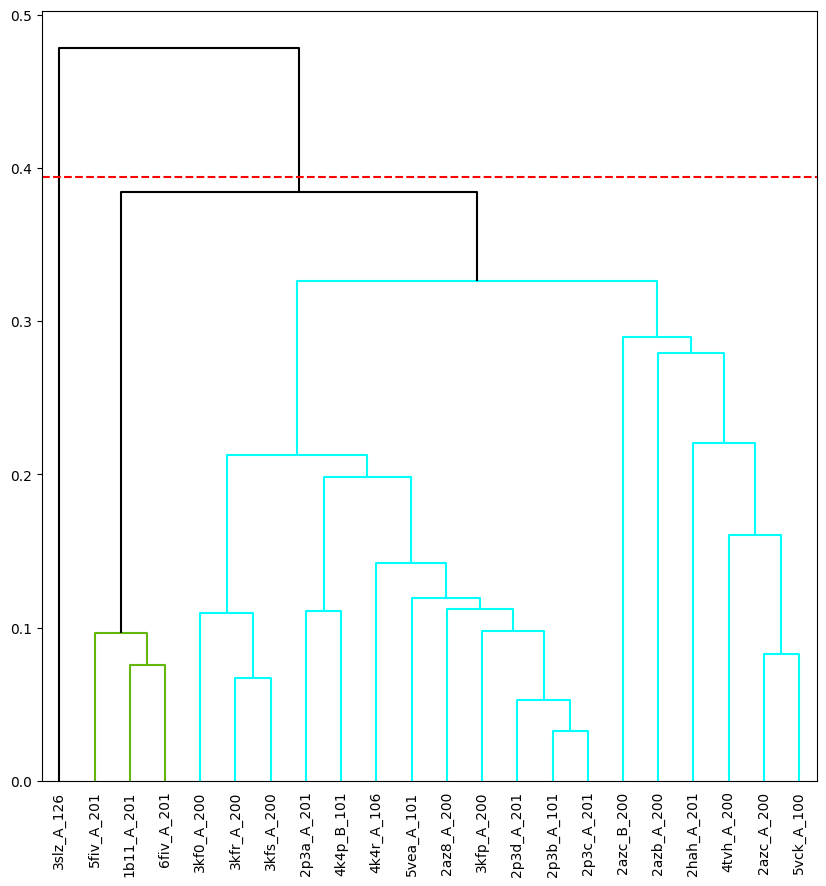

In [ ]:
fig = plt.figure(figsize=(10, 10))
dend = dendrogram(
    linkage_matrix[:, :4],
    color_threshold=0.384,
    above_threshold_color='black',
    labels=chem_comp_ids,
    link_color_func=link_color_func,
    leaf_font_size=10,
    leaf_rotation=90
)
plt.axhline(y=cut_off+0.01, color='red', linestyle='--')
plt.show()

In [13]:
len(clusters[ligand_id]['clusters'])

3

In [17]:
clusters[ligand_id]['clusters']['1']

{'complexes': ['1b11_bm5', '5fiv_bm1', '6fiv_bm3'], 'rep': '1b11_bm5'}

In [15]:
clusters[ligand_id]['clusters']['2']

{'complexes': ['2azc_bm1',
  '2azc_bm2',
  '2az8_bm1',
  '2azb_bm1',
  '2hah_bm1',
  '2p3a_bm1',
  '2p3b_bm1',
  '2p3c_bm1',
  '2p3d_bm1',
  '3kf0_bm1',
  '3kfr_bm1',
  '3kfp_bm1',
  '3kfs_bm1',
  '4k4p_bm2',
  '4k4r_bm6',
  '4tvh_bm1',
  '5vck_bm1',
  '5vea_bm1'],
 'rep': '4tvh_bm1'}

In [22]:
clusters[ligand_id]['clusters']['2']['rep']

'4tvh_bm1'

In [16]:
clusters[ligand_id]['clusters']['3']

{'complexes': ['3slz_bm1'], 'rep': '3slz_bm1'}